# 公司变量的 PEID 因果超图

本 notebook 复现公司财务变量的单尺度 PEID 分析。核心计算保留在 `scripts/company_ce/peid_causal_hypergraph.py` 中，这里只暴露主要参数，便于手动调节。

## 0. 因果问题与识别边界

本实验的因果问题是：在公司年度面板中，时刻 `t` 的离散增长状态对时刻 `t+1` 的变量状态包含多少 PEID/EI 意义下的有效信息？人口总体是可构造连续年度转移样本的公司-年份观测，处理/来源变量是 `VARIABLES` 中各变量在 `t` 的离散状态，结果变量是同一变量集合在 `t+1` 的离散状态。

理论依据采用 Yang 等（2026）《Partial Effective Information Decomposition for Synergistic Causality》：PEID 在最大熵干预语义下，将多个来源变量对目标变量的有效信息分解为单变量贡献与协同贡献，并允许用有向边和超边表示协同因果结构。因此，本 notebook 的“因果图”是 PEID/EI 意义下的跨期有效信息图。

识别边界需要明确：这不是干预效应估计，也不是 DoWhy/SCM 后门识别后的平均处理效应。当前数据是观察性公司财务面板，潜在混杂包括行业、宏观周期、公司年龄、治理结构、融资约束、并购事件和会计制度差异等。时间顺序 `t -> t+1` 排除了同一时间片内的反向边，但不能单独排除所有未观测混杂。因此，结论应写成“候选跨期机制”“PEID 有效信息边”或“协同信息结构”，而不是现实经营干预的确定因果效应。


## 1. 参数

编辑此单元可以调整变量集合、离散化粒度、零分布重复次数、样本支持阈值和绘图的 Top-K 数量。将 `RUN_ANALYSIS = False` 设为关闭时，会复用已缓存的 CSV 输出，只重新读取或绘制图表。

### 可调参数中文说明

| 参数 | 中文说明 | 调参影响 |
|---|---|---|
| `SMOKE` | 是否启用快速烟雾测试模式；由环境变量 `PEID_NOTEBOOK_SMOKE=1` 控制。 | 开启后变量数、零分布重复次数和 Top-K 会变小，用于检查流程，不适合作为正式证据。 |
| `VARIABLES` | 纳入 PEID 分析的公司变量集合；默认包含总资产、营业收入、员工数、长期债务、总负债和现金。 | 变量越多，可能发现更多边，但联合状态支持度会下降，计算量也会上升。 |
| `BINS` | 连续增长率离散化的分箱数。 | 值越大，状态更细；但每个状态的样本数更少，结果更依赖支持度阈值。 |
| `MAX_SOURCE_ORDER` | PEID 协同超边允许的最大源集合阶数。 | `2` 表示只看二元协同；提高到 `3` 会搜索三变量联合来源，计算量和稀疏风险明显增加。 |
| `ALPHA` | 条件概率估计中的 Dirichlet/Laplace 平滑强度。 | 值越大，低频状态被更强平滑；可降低稀疏噪声，但会压低极端转移差异。 |
| `MIN_SOURCE_COUNT` | 单个源状态进入 EI 估计所需的最小样本数。 | 提高后结果更稳健，但会丢弃低支持状态；降低后可保留稀有状态，但噪声更大。 |
| `MIN_TOTAL_COUNT` | 构建完整跨期转移样本所需的最小总样本数。 | 防止在样本过少时继续估计；通常不建议低于默认值。 |
| `NULL_REPS` | 每种零分布随机置换的重复次数。 | 正式比较时应提高到 100 或更多；当前小值主要用于快速迭代。 |
| `TOP_K` | 图和摘要中展示的 Top 边数量。 | 增大可展示更多边，但图会更密；减小可突出主干关系。 |
| `RANDOM_SEED` | 零分布置换的随机种子。 | 固定后便于复现；改变后可检查随机置换结果是否稳定。 |
| `YEAR_START` | 样本起始年份；`None` 表示不限制。 | 用于考察特定时期的跨期机制。 |
| `YEAR_END` | 样本结束年份；`None` 表示不限制。 | 可与 `YEAR_START` 配合做时期截面或稳健性分析。 |
| `WINSOR_LOWER` | 对非正值较多变量使用 signed relative change 时的下侧缩尾分位数。 | 提高会更强地截断负向极端值；默认只做轻度缩尾。 |
| `WINSOR_UPPER` | 对 signed relative change 的上侧缩尾分位数。 | 降低会更强地截断正向极端值；需与下侧缩尾保持一致解释。 |
| `RUN_ANALYSIS` | 是否重新运行完整 PEID 分析。 | `True` 会重新计算 CSV 和图；`False` 适合只复用缓存结果。 |
| `REUSE_CACHE_WHEN_NOT_RUNNING` | 当不重新运行时，是否允许复用已有 CSV 缓存。 | 通常保持 `True`；若缓存缺失或参数改变，应重新运行。 |
| `INPUT_PATH` | 输入公司年度数据 CSV 的路径。 | 更换数据源时需要同步检查变量名和年份字段。 |
| `OUTPUT_DIR` | 结果 CSV 的输出目录。 | 建议按实验版本区分目录，避免覆盖正式结果。 |
| `FIGURE_DIR` | 图文件输出目录。 | notebook 下方展示的 PNG 也从这里读取；脚本同时导出 PDF 便于论文排版。 |


In [18]:
from pathlib import Path
import os
import sys

import pandas as pd
from IPython.display import Image, display

# 路径设置：无论从仓库根目录还是 notebook 目录启动，都能定位项目根目录。
REPO_CWD = Path.cwd().resolve()
candidates = [REPO_CWD, *REPO_CWD.parents]
PROJECT_ROOT = next(path for path in candidates if (path / "AGENTS.md").exists() and (path / "data" / "inf_compustat_anual_US_filter_feas.csv").exists())

SRC_DIR = PROJECT_ROOT / "scripts" / "company_ce"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from peid_causal_hypergraph import PeidConfig, plot_outputs, run_peid_analysis

# `SMOKE`：快速烟雾测试开关；设置环境变量 PEID_NOTEBOOK_SMOKE=1 时启用。
SMOKE = os.getenv("PEID_NOTEBOOK_SMOKE") == "1"

# `VARIABLES`：参与跨期 EI/PEID 估计的变量集合；正式结果默认使用 6 个公司财务变量。
VARIABLES = ["at", "revt", "emp"] if SMOKE else ["at", "revt", "emp", "dltt", "lt", "ch"]
# `BINS`：增长率离散状态数；默认三分位能在状态分辨率和样本支持之间折中。
BINS = 5
# `MAX_SOURCE_ORDER`：协同超边的最大源集合阶数；默认只估计二元协同，避免状态空间过稀。
MAX_SOURCE_ORDER = 2
# `ALPHA`：条件转移概率的平滑强度；用于减少低频状态导致的零概率问题。
ALPHA = 0.5
# `MIN_SOURCE_COUNT`：每个源状态的最小样本支持；过低会放大稀疏噪声。
MIN_SOURCE_COUNT = 10 if SMOKE else 20
# `MIN_TOTAL_COUNT`：完整跨期样本的最低数量要求；样本不足时停止估计。
MIN_TOTAL_COUNT = 100
# `NULL_REPS`：每种零分布置换重复次数；正式证据建议提高到 100 或更多。
NULL_REPS = 2 if SMOKE else 20
# `TOP_K`：图和结果表展示的最强边数量；图过密时优先减小该值。
TOP_K = 5 if SMOKE else 12
# `RANDOM_SEED`：零分布随机置换种子；固定后便于复现实验。
RANDOM_SEED = 42
# `YEAR_START` / `YEAR_END`：样本年份窗口；None 表示使用全部年份。
YEAR_START = None
YEAR_END = None
# `WINSOR_LOWER` / `WINSOR_UPPER`：signed relative change 的上下缩尾分位数。
WINSOR_LOWER = 0.01
WINSOR_UPPER = 0.99
# `RUN_ANALYSIS`：是否重新运行完整计算；False 时只复用缓存并重画图/读表。
RUN_ANALYSIS = True
# `REUSE_CACHE_WHEN_NOT_RUNNING`：不重跑时是否允许读取已有 CSV 缓存。
REUSE_CACHE_WHEN_NOT_RUNNING = True

# `INPUT_PATH`：输入公司年度数据；`OUTPUT_DIR`：CSV 输出；`FIGURE_DIR`：PNG/PDF 图输出。
INPUT_PATH = PROJECT_ROOT / "data" / "inf_compustat_anual_US_filter_feas.csv"
OUTPUT_DIR = PROJECT_ROOT / "results" / "company_ce" / "csv" / ("peid_notebook_smoke" if SMOKE else "peid")
FIGURE_DIR = PROJECT_ROOT / "fig" / "company_ce" / ("peid_notebook_smoke" if SMOKE else "peid")

config = PeidConfig(
    input_path=str(INPUT_PATH),
    output_dir=str(OUTPUT_DIR),
    figure_dir=str(FIGURE_DIR),
    variables=tuple(VARIABLES),
    bins=BINS,
    max_source_order=MAX_SOURCE_ORDER,
    alpha=ALPHA,
    min_source_count=MIN_SOURCE_COUNT,
    min_total_count=MIN_TOTAL_COUNT,
    null_reps=NULL_REPS,
    top_k=TOP_K,
    random_seed=RANDOM_SEED,
    year_start=YEAR_START,
    year_end=YEAR_END,
    winsor_lower=WINSOR_LOWER,
    winsor_upper=WINSOR_UPPER,
)

config


PeidConfig(input_path='/Users/yangmingzhe/Desktop/code/github/EISyn/data/inf_compustat_anual_US_filter_feas.csv', output_dir='/Users/yangmingzhe/Desktop/code/github/EISyn/results/company_ce/csv/peid', figure_dir='/Users/yangmingzhe/Desktop/code/github/EISyn/fig/company_ce/peid', variables=('at', 'revt', 'emp', 'dltt', 'lt', 'ch'), bins=5, max_source_order=2, alpha=0.5, min_source_count=20, min_total_count=100, null_reps=20, top_k=12, random_seed=42, year_start=None, year_end=None, winsor_lower=0.01, winsor_upper=0.99)

## 2. 运行或复用分析

这一步会构建离散的公司-年份转移样本，估计成对 EI 和 PEID 协同超边，执行零分布随机置换，写出 CSV 文件，并保存结果图。

In [19]:
#TODO: 这个cell的运行结果要有缓存，避免每次都重新计算。可以考虑在 `run_peid_analysis` 内部实现一个简单的缓存机制，比如先检查输出目录下是否已经存在结果 CSV 文件，如果存在且 `RUN_ANALYSIS` 为 False，则直接读取并返回结果，而不是重新计算。

result = run_peid_analysis(
    config,
    skip_figures=False,
    reuse_cache=(not RUN_ANALYSIS and REUSE_CACHE_WHEN_NOT_RUNNING),
)
result

{'output_dir': '/Users/yangmingzhe/Desktop/code/github/EISyn/results/company_ce/csv/peid',
 'figure_dir': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/company_ce/peid',
 'reused_cache': 'false'}

## 3. 加载结果表

审计表用于检查数据覆盖率和变量变换情况。边表是下方各图的直接数据来源。

In [20]:
audit = pd.read_csv(OUTPUT_DIR / "peid_variable_audit.csv")
pairwise = pd.read_csv(OUTPUT_DIR / "peid_pairwise_edges.csv")
synergy = pd.read_csv(OUTPUT_DIR / "peid_synergy_hyperedges.csv")
top_edges = pd.read_csv(OUTPUT_DIR / "peid_top_edges_for_figures.csv")

print("输出表：", OUTPUT_DIR)
print("图目录：", FIGURE_DIR)
display(audit)
display(pairwise.head(TOP_K))
display(synergy.head(TOP_K))

输出表： /Users/yangmingzhe/Desktop/code/github/EISyn/results/company_ce/csv/peid
图目录： /Users/yangmingzhe/Desktop/code/github/EISyn/fig/company_ce/peid


,variable,transform,n_level_rows,n_positive_rows,n_growth_rows,n_firms,growth_mean,growth_std,n_complete_growth_rows,n_complete_transition_pairs,n_complete_transition_firms
0,at,log_growth,500827,499741,461955,35969,0.122709,0.588659,270481,236082,23914
1,revt,log_growth,465630,455920,418222,33318,0.111311,0.553198,270481,236082,23914
2,emp,log_growth,399009,394819,356092,30440,0.041585,0.414691,270481,236082,23914
3,dltt,signed_relative_change,474358,389937,430540,35551,0.631395,3.275677,270481,236082,23914
4,lt,log_growth,478266,477993,440048,35512,0.127640,0.606854,270481,236082,23914
5,ch,log_growth,412439,405386,363589,33155,0.093045,1.221645,270481,236082,23914


,source,target,ei,source_support,total_count,row_sum_error,null_mean,null_std,z_score,p_value
0,dltt,dltt,0.142505,5,236082,0.000000e+00,0.039751,0.040215,2.555124,0.02439
1,at,revt,0.132648,5,236082,1.110223e-16,0.018561,0.018751,6.084244,0.02439
2,revt,revt,0.127426,5,236082,1.110223e-16,0.036723,0.037142,2.442043,0.02439
3,at,at,0.124091,5,236082,0.000000e+00,0.038025,0.038464,2.237577,0.02439
4,emp,revt,0.121365,5,236082,1.110223e-16,0.015833,0.015986,6.601672,0.02439
5,emp,emp,0.095762,5,236082,1.110223e-16,0.035615,0.036022,1.669749,0.02439
6,lt,revt,0.087789,5,236082,0.000000e+00,0.011913,0.012020,6.312363,0.02439
7,revt,at,0.084378,5,236082,1.110223e-16,0.017997,0.018184,3.650411,0.02439
8,at,emp,0.083041,5,236082,0.000000e+00,0.016940,0.017111,3.863002,0.02439
9,emp,at,0.080221,5,236082,0.000000e+00,0.016755,0.016911,3.752918,0.02439


,sources,target,source_order,joint_ei,single_ei_sum,synergy_raw,synergy,source_support,total_count,row_sum_error,null_mean,null_std,z_score,p_value
0,dltt+lt,dltt,2,0.177348,0.161991,0.015357,0.015357,25,236082,2.220446e-16,0.000173,0.000183,82.972589,0.024390
1,at+dltt,dltt,2,0.171128,0.164252,0.006876,0.006876,25,236082,1.110223e-16,0.000128,0.000134,50.363035,0.024390
2,at+dltt,emp,2,0.093340,0.090462,0.002878,0.002878,25,236082,2.220446e-16,0.000127,0.000133,20.712185,0.024390
3,at+ch,ch,2,0.080497,0.078988,0.001510,0.001510,25,236082,1.110223e-16,0.000110,0.000115,12.188155,0.024390
4,at+ch,dltt,2,0.024036,0.022607,0.001429,0.001429,25,236082,1.110223e-16,0.000109,0.000099,13.279240,0.024390
5,dltt+ch,dltt,2,0.144367,0.143364,0.001003,0.001003,25,236082,1.110223e-16,0.000184,0.000083,9.929049,0.024390
6,dltt+ch,ch,2,0.069809,0.069341,0.000469,0.000469,25,236082,1.110223e-16,0.000159,0.000068,4.538531,0.024390
7,at+dltt,at,2,0.135210,0.134789,0.000421,0.000421,25,236082,2.220446e-16,0.000123,0.000127,2.343840,0.024390
8,at+dltt,ch,2,0.012718,0.011530,0.001187,0.001187,25,236082,1.110223e-16,0.000659,0.000433,1.220724,0.121951
9,dltt+lt,emp,2,0.047565,0.047238,0.000328,0.000328,25,236082,1.110223e-16,0.000158,0.000167,1.016160,0.195122


## 4. 成对 EI 热图

这张热图回答：时刻 `t` 的哪个变量，对时刻 `t+1` 的哪个变量包含最强的有效信息？行表示源变量，列表示目标变量，颜色表示以 bit 为单位的 EI。

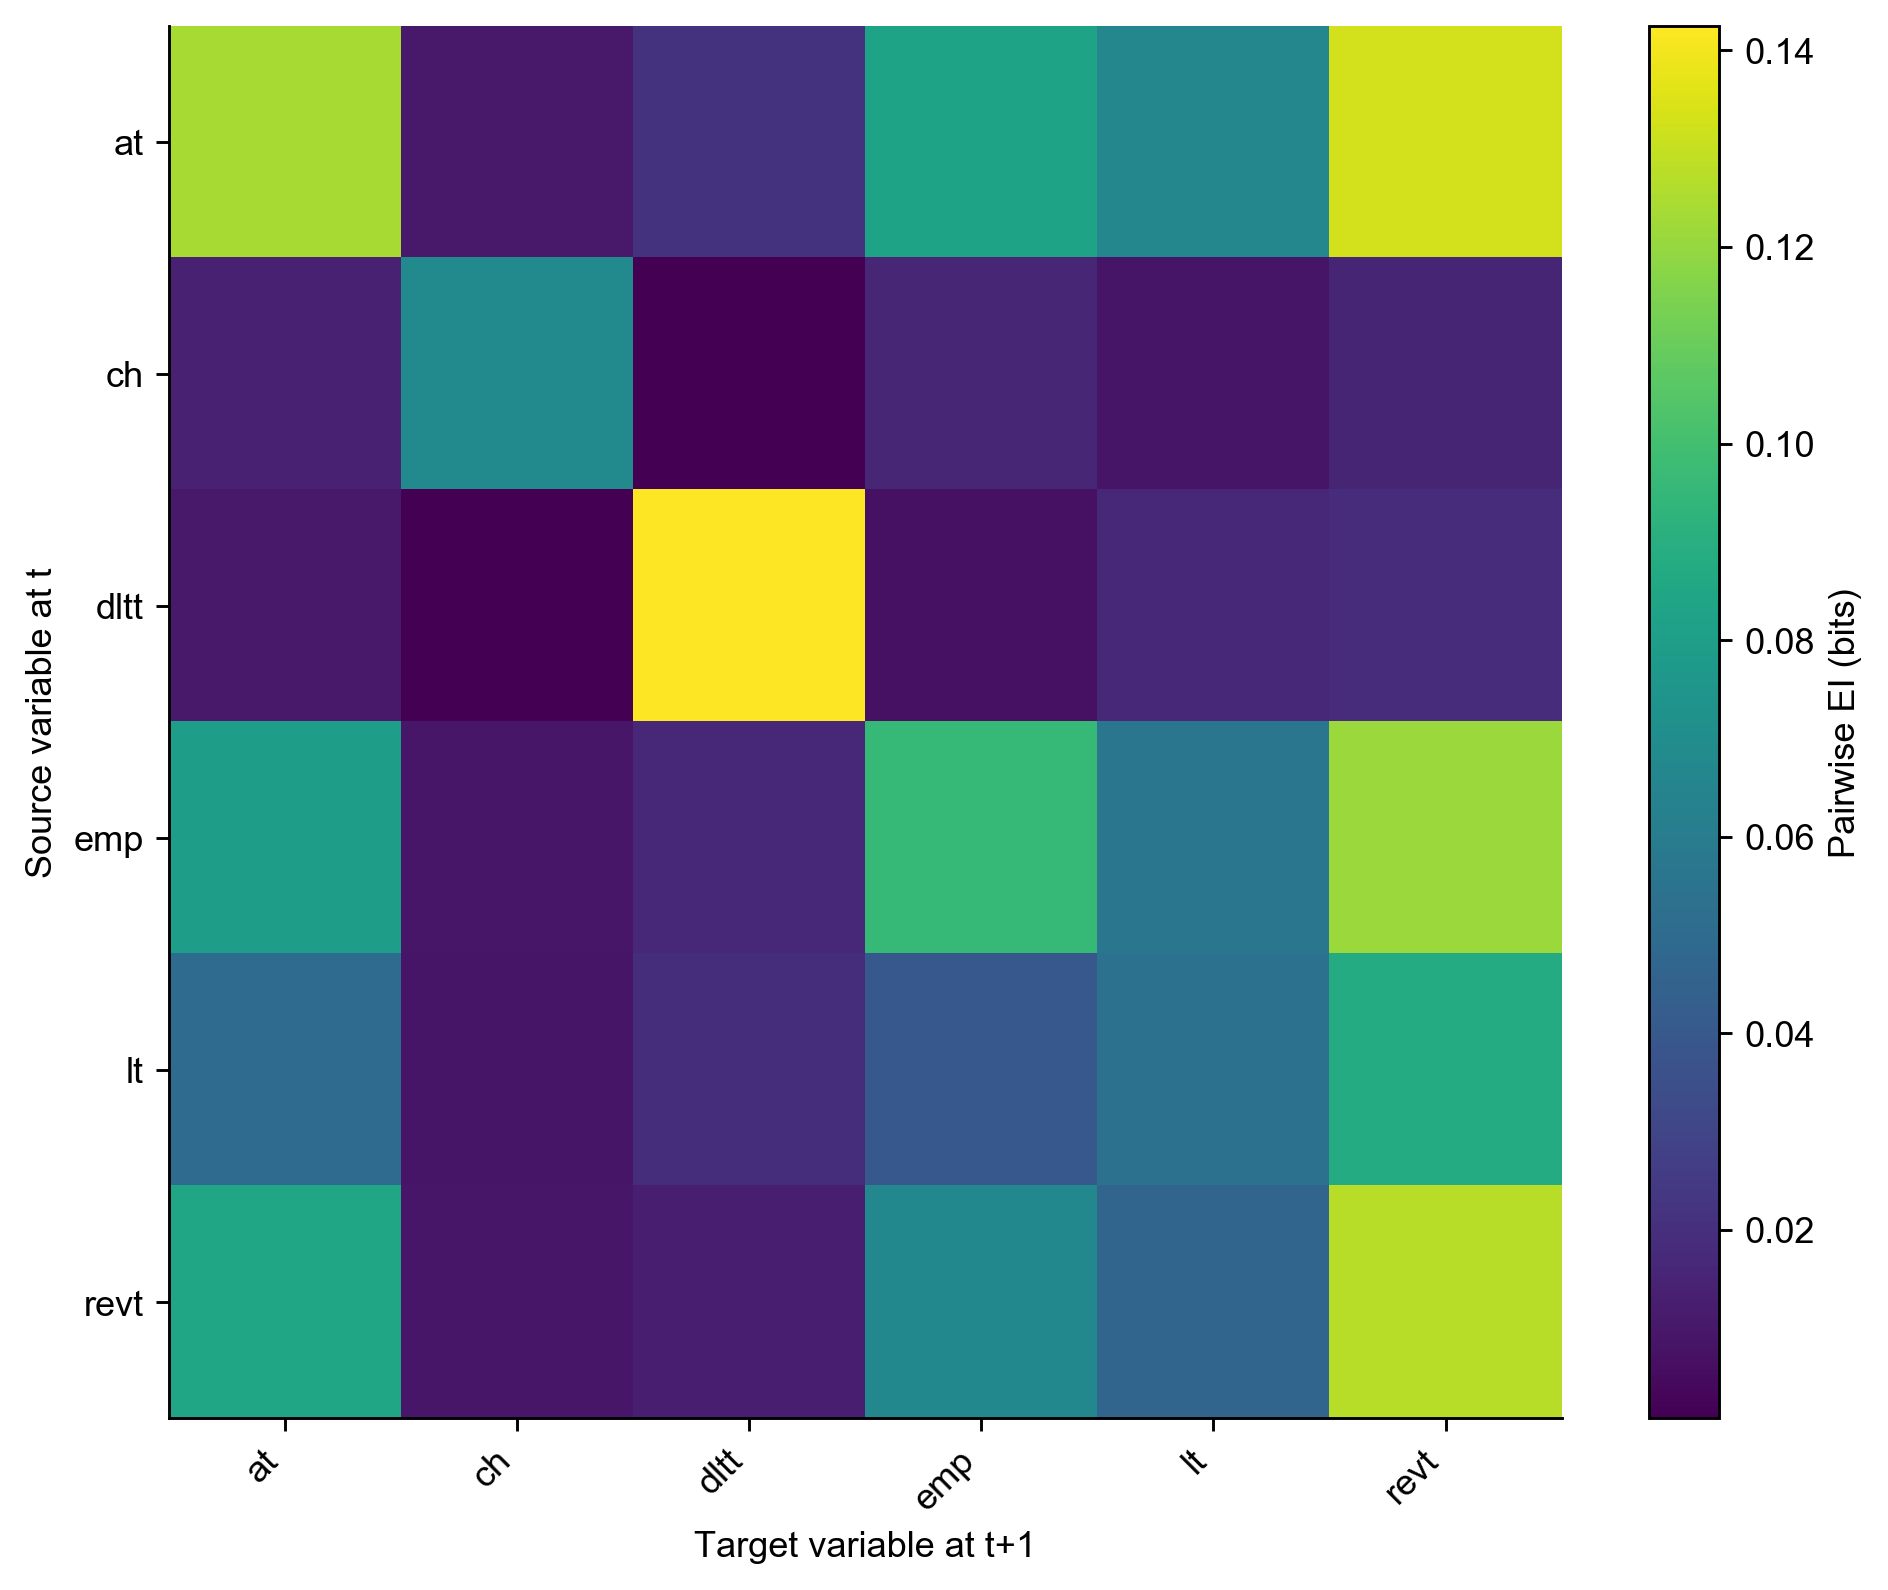

In [21]:
display(Image(filename=str(FIGURE_DIR / "peid_pairwise_ei_heatmap.png")))

## 4.5 因果证据汇总

主因果图只保留结构和线宽，避免在边上堆叠数字。下面的证据汇总图集中展示 Top 成对边和 Top 协同超边相对零分布均值的超额信息量，并在标签中列出经验 p 值。横轴越大，说明观测信息量相对随机置换越强。

In [ ]:
display(Image(filename=str(FIGURE_DIR / "peid_causal_evidence_summary.png")))


### 证据汇总结果分析

成对边的超额信息量明显大于协同超边，说明当前公司变量系统的主要跨期结构由单变量来源即可捕捉；协同超边的作用更像是在负债、现金和规模变量组合上补充局部机制。`at -> revt`、`emp -> revt`、`revt -> revt` 等边同时具备较高 EI 和较低经验 p 值，是最值得作为候选机制讨论的主干边。

协同部分中，`{dltt, lt} -> dltt`、`{at, dltt} -> emp`、`{at, ch} -> ch` 的超额信息最突出，说明联合来源确实提供了单变量 EI 加总之外的额外信息。但这些 synergy 的绝对量级远小于成对 EI，因此结论应强调“协同结构存在但不是主导结构”。如果要把协同超边作为论文中的核心发现，需要进一步提高 `NULL_REPS`，并比较不同 `BINS`、年份窗口和变量集合下的稳定性。


## 5. Top 成对因果图

这张图把时刻 `t` 的源变量放在左侧，把时刻 `t+1` 的目标变量放在右侧，展示按零分布排名筛选后的 Top 成对 EI 边。边宽随 EI 强度变化，边颜色不再区分类别；具体 EI、零分布和 p 值见证据汇总图。它表示跨期机制信息关系，而不是同期观测相关关系。


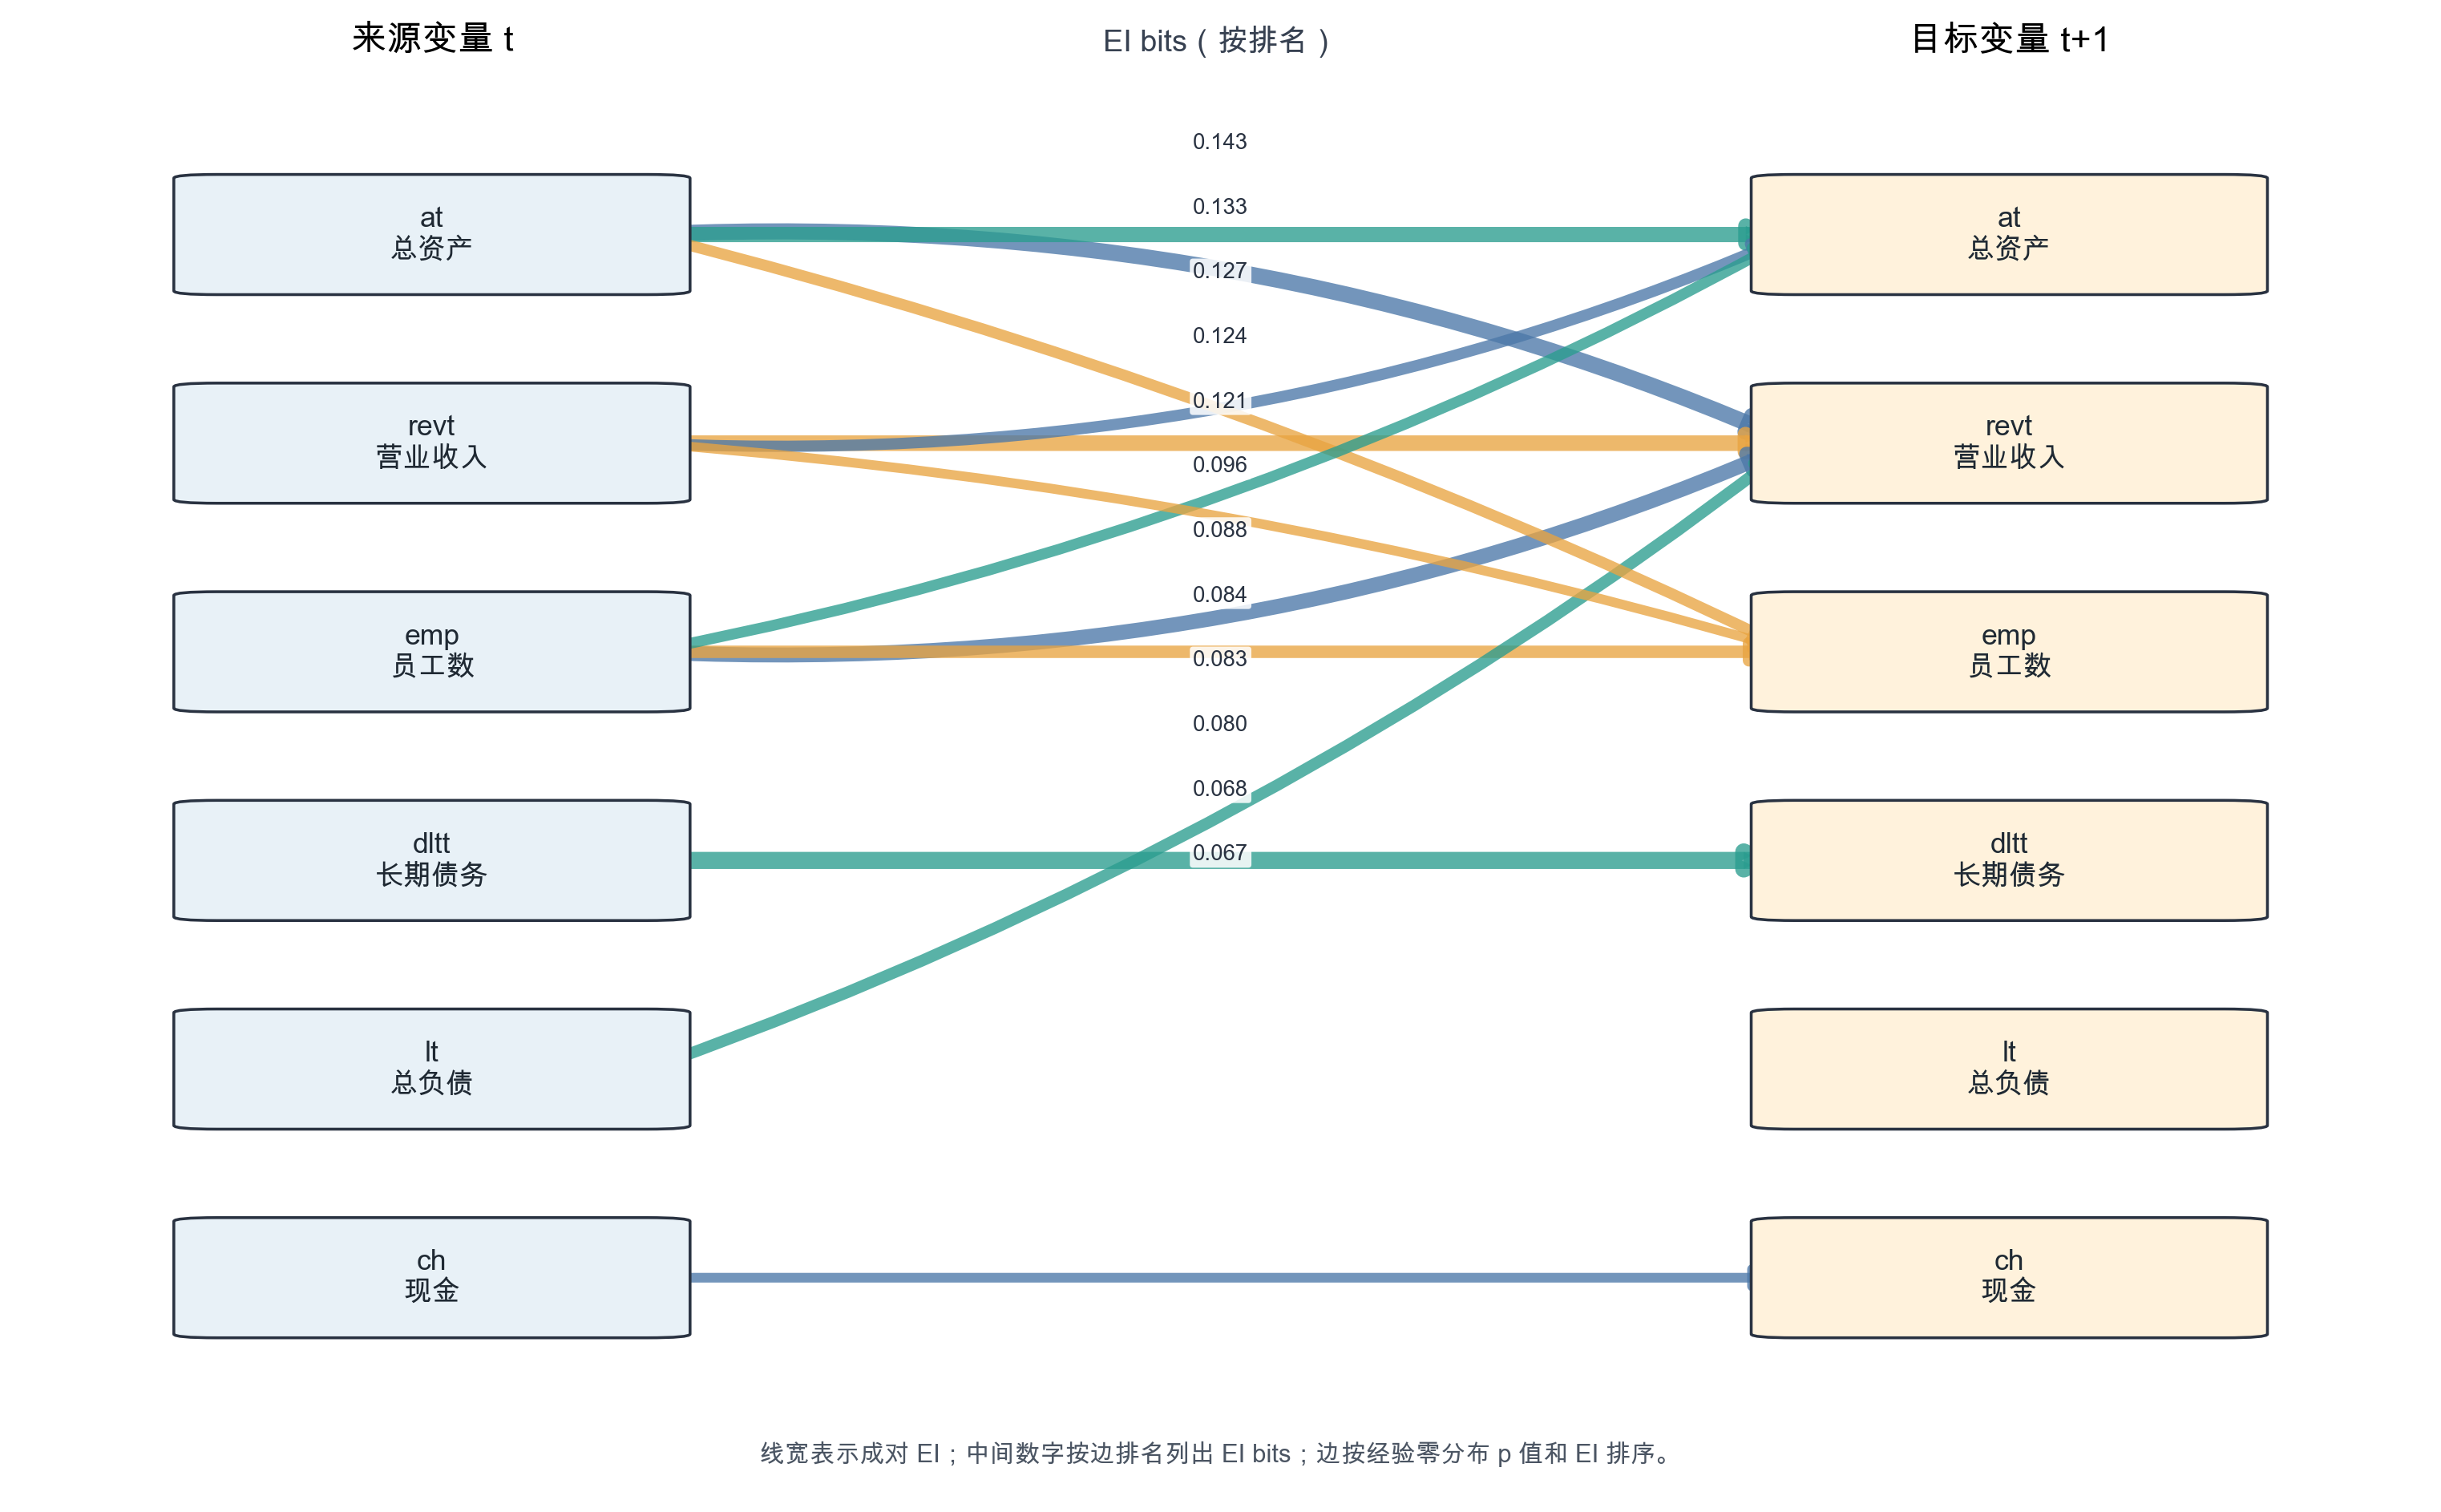

In [22]:
display(Image(filename=str(FIGURE_DIR / "peid_top_pairwise_graph.png")))

### 因果图结果分析

当前默认参数下，成对因果图的主干集中在规模、收入和雇员变量：`at -> revt` 的 EI 最高（约 0.088 bits），随后是 `at -> at`、`emp -> revt` 和 `revt -> revt`。这说明总资产和雇员规模对下一期营业收入有较强的跨期有效信息，同时总资产、营业收入、长期债务和员工数都存在明显的自回归信息。这里的“因果”含义是 PEID/EI 意义下的最大熵干预信息结构，不是对某个具体政策或经营干预的平均处理效应估计。

**结论：** 公司变量的跨期信息结构不是由单一变量驱动，而是以“资产规模/收入/雇员规模”的信息主干为核心；其中 `at` 同时连接 `revt`、`at`、`emp` 和 `lt`，更像是默认参数下的核心源变量。因果解释应表述为“候选跨期机制边”或“PEID 意义下的有效信息边”，不能直接表述为资产增长会在现实干预中必然提高收入。当前 `NULL_REPS = 20` 时最小经验 p 值约为 0.024，适合筛选候选机制；若写入正式论文证据，应提高零分布重复次数后再确认 p 值和 z 分数。


## 6. Top PEID 协同超图

每个源集合节点（例如 `{at, revt}`）在对某个目标变量产生正的截断协同时，会指向该目标变量。边宽表示联合来源超过单变量 EI 加总的额外信息量，边颜色不再编码额外类别；具体 synergy、零分布和 p 值见证据汇总图。CSV 中同时保留原始协同值和截断后的正协同值。


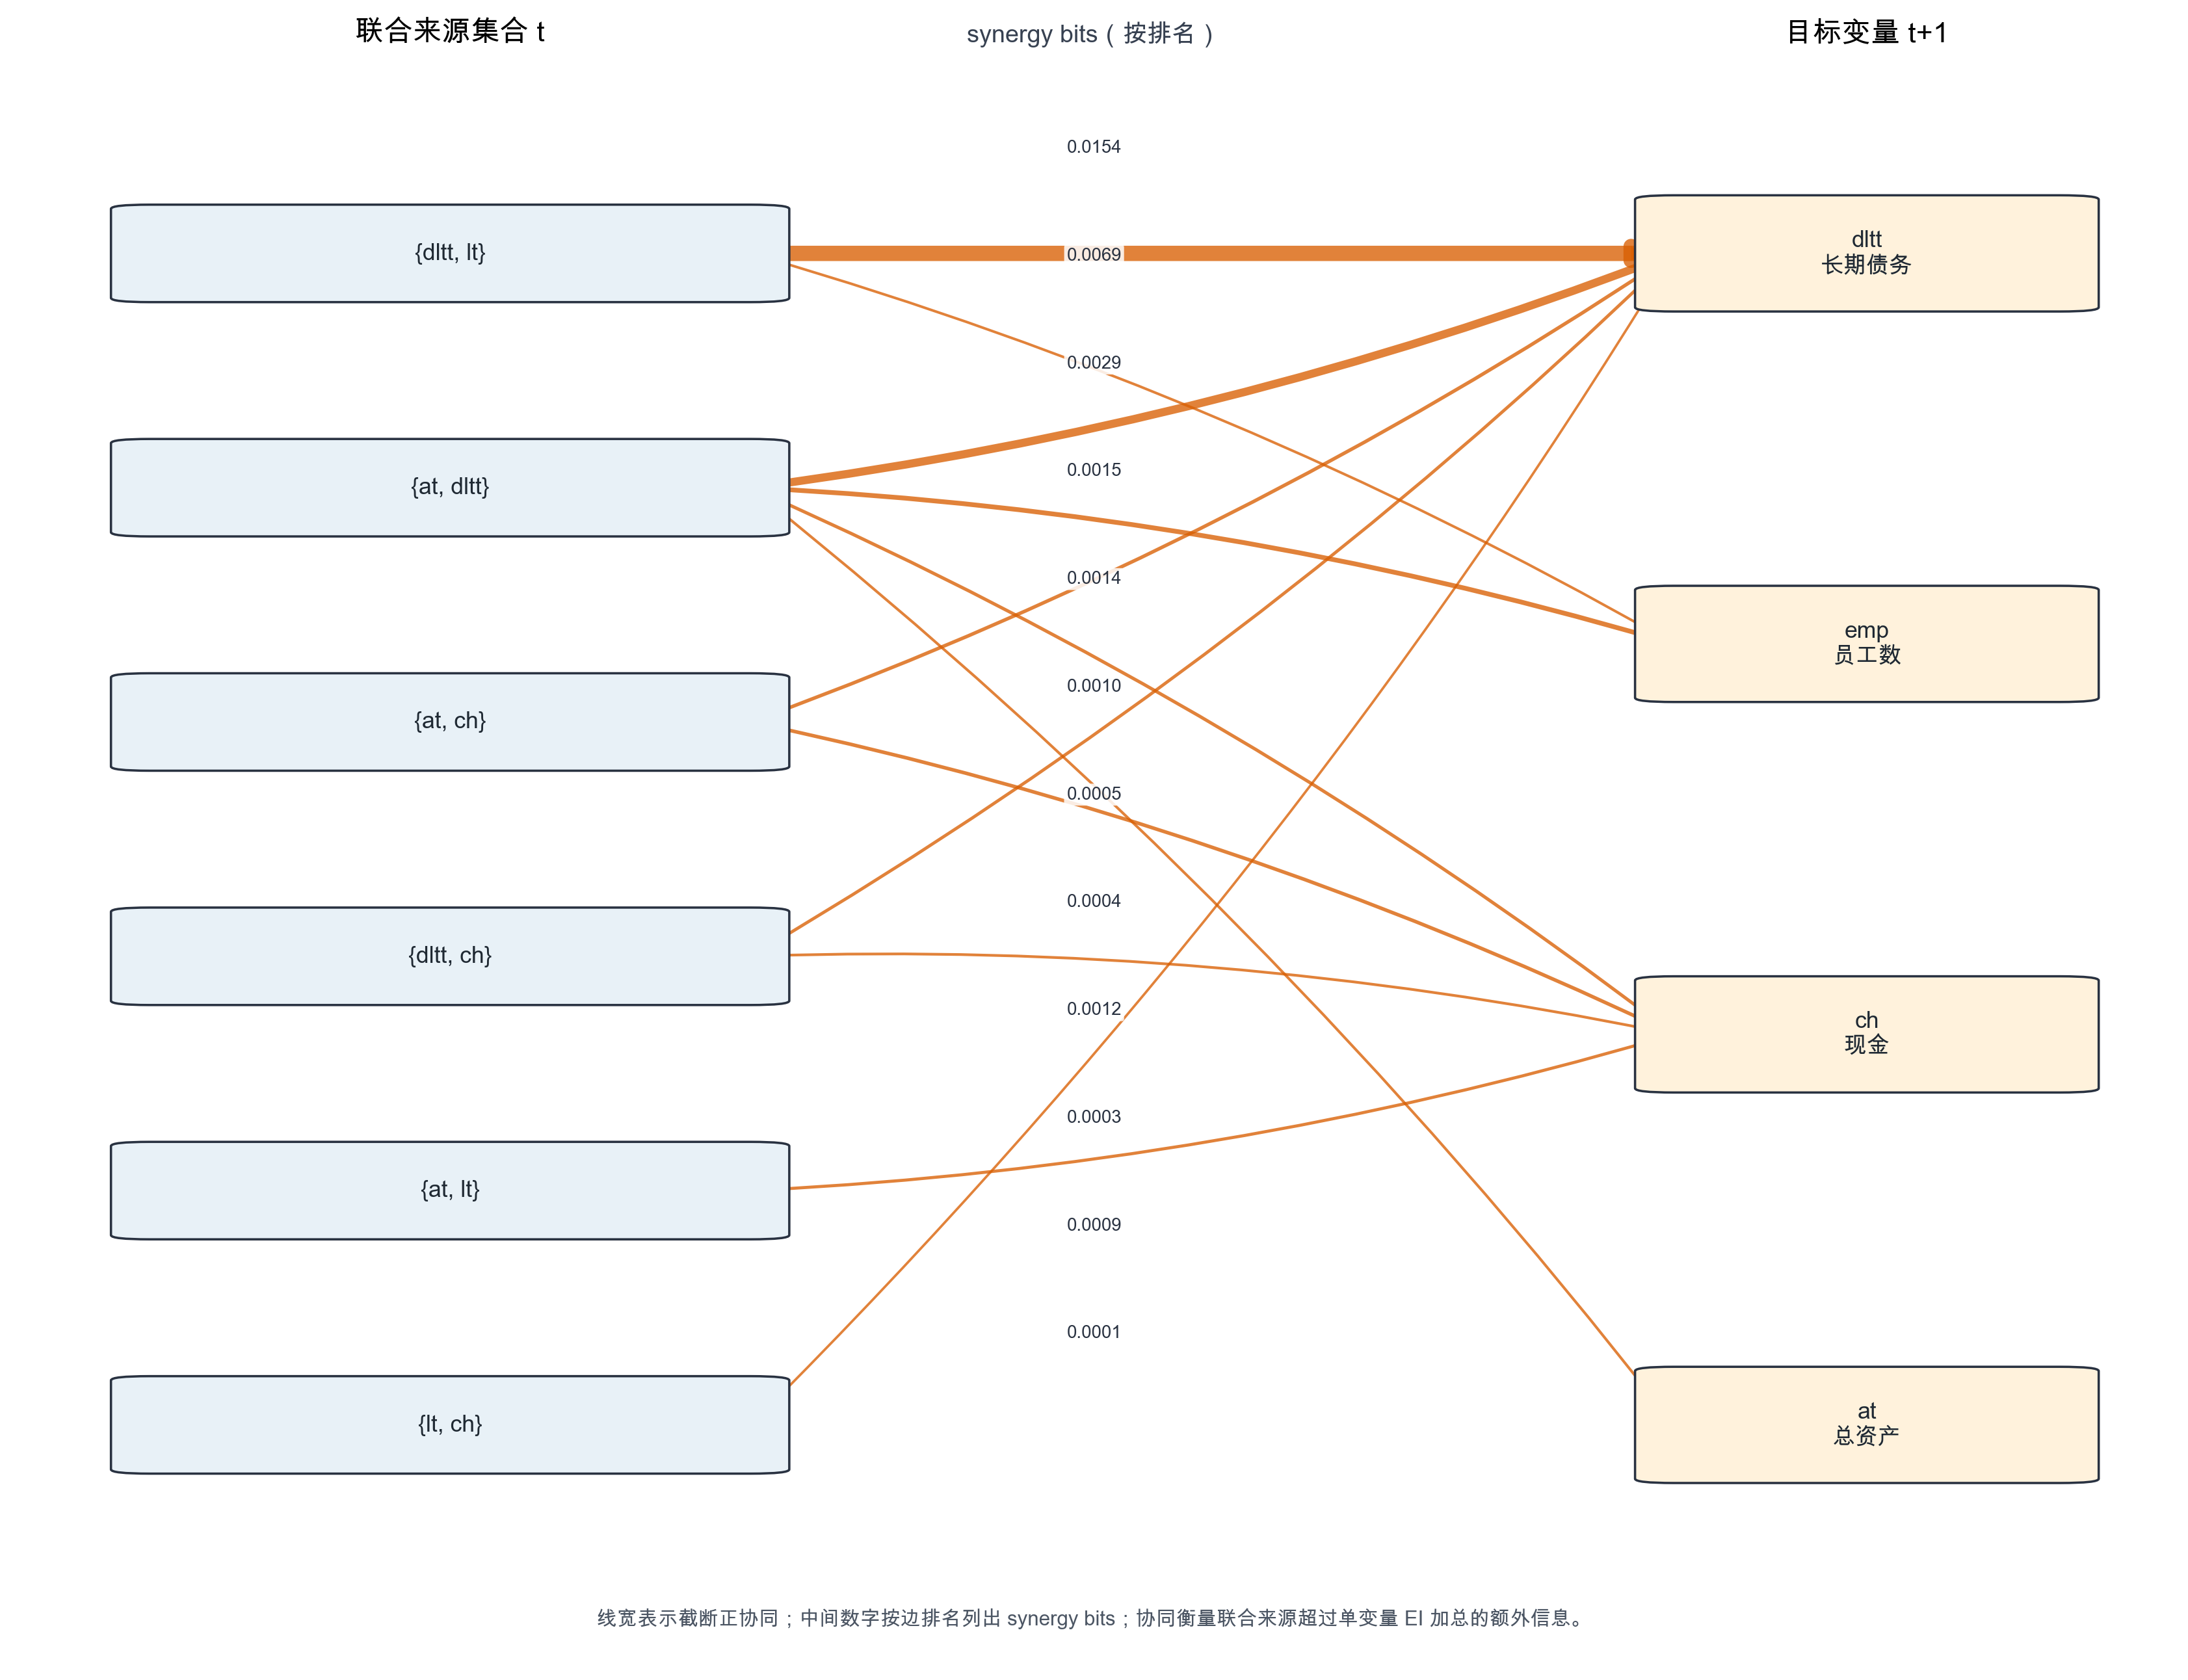

In [23]:
display(Image(filename=str(FIGURE_DIR / "peid_top_synergy_hypergraph.png")))

### 协同超图结果分析

协同超图显示，额外联合信息主要出现在负债结构和规模变量组合中。当前最强协同边是 `{dltt, lt} -> dltt`（synergy 约 0.0058 bits），其次是 `{at, dltt} -> emp` 和 `{at, ch} -> ch`。这些协同值的绝对量级小于成对 EI，但远高于对应零分布均值，说明某些目标变量需要联合来源才能解释一小部分单变量边无法覆盖的信息。

**结论：** 成对 EI 给出跨期信息主干，PEID 协同超边给出补充机制：负债总量与长期债务共同刻画下一期长期债务状态，资产与长期债务共同补充员工数变化的信息，资产与现金共同补充现金状态的信息。协同超边应解释为联合来源在最大熵干预分布下提供的额外有效信息，而不是两个变量在观测样本中共同变化导致的普通相关性。因此，默认结果更支持“主干由强成对边决定，协同边提供局部补充解释”的因果图解读，而不是把协同超边视为替代成对因果边的主要结构。


## 7. 零分布比较

这张图比较 Top 边的观测 EI/协同值与零分布均值。若要将 p 值或 z 分数作为正式证据，请先把 `NULL_REPS` 提高到 100 或更多。

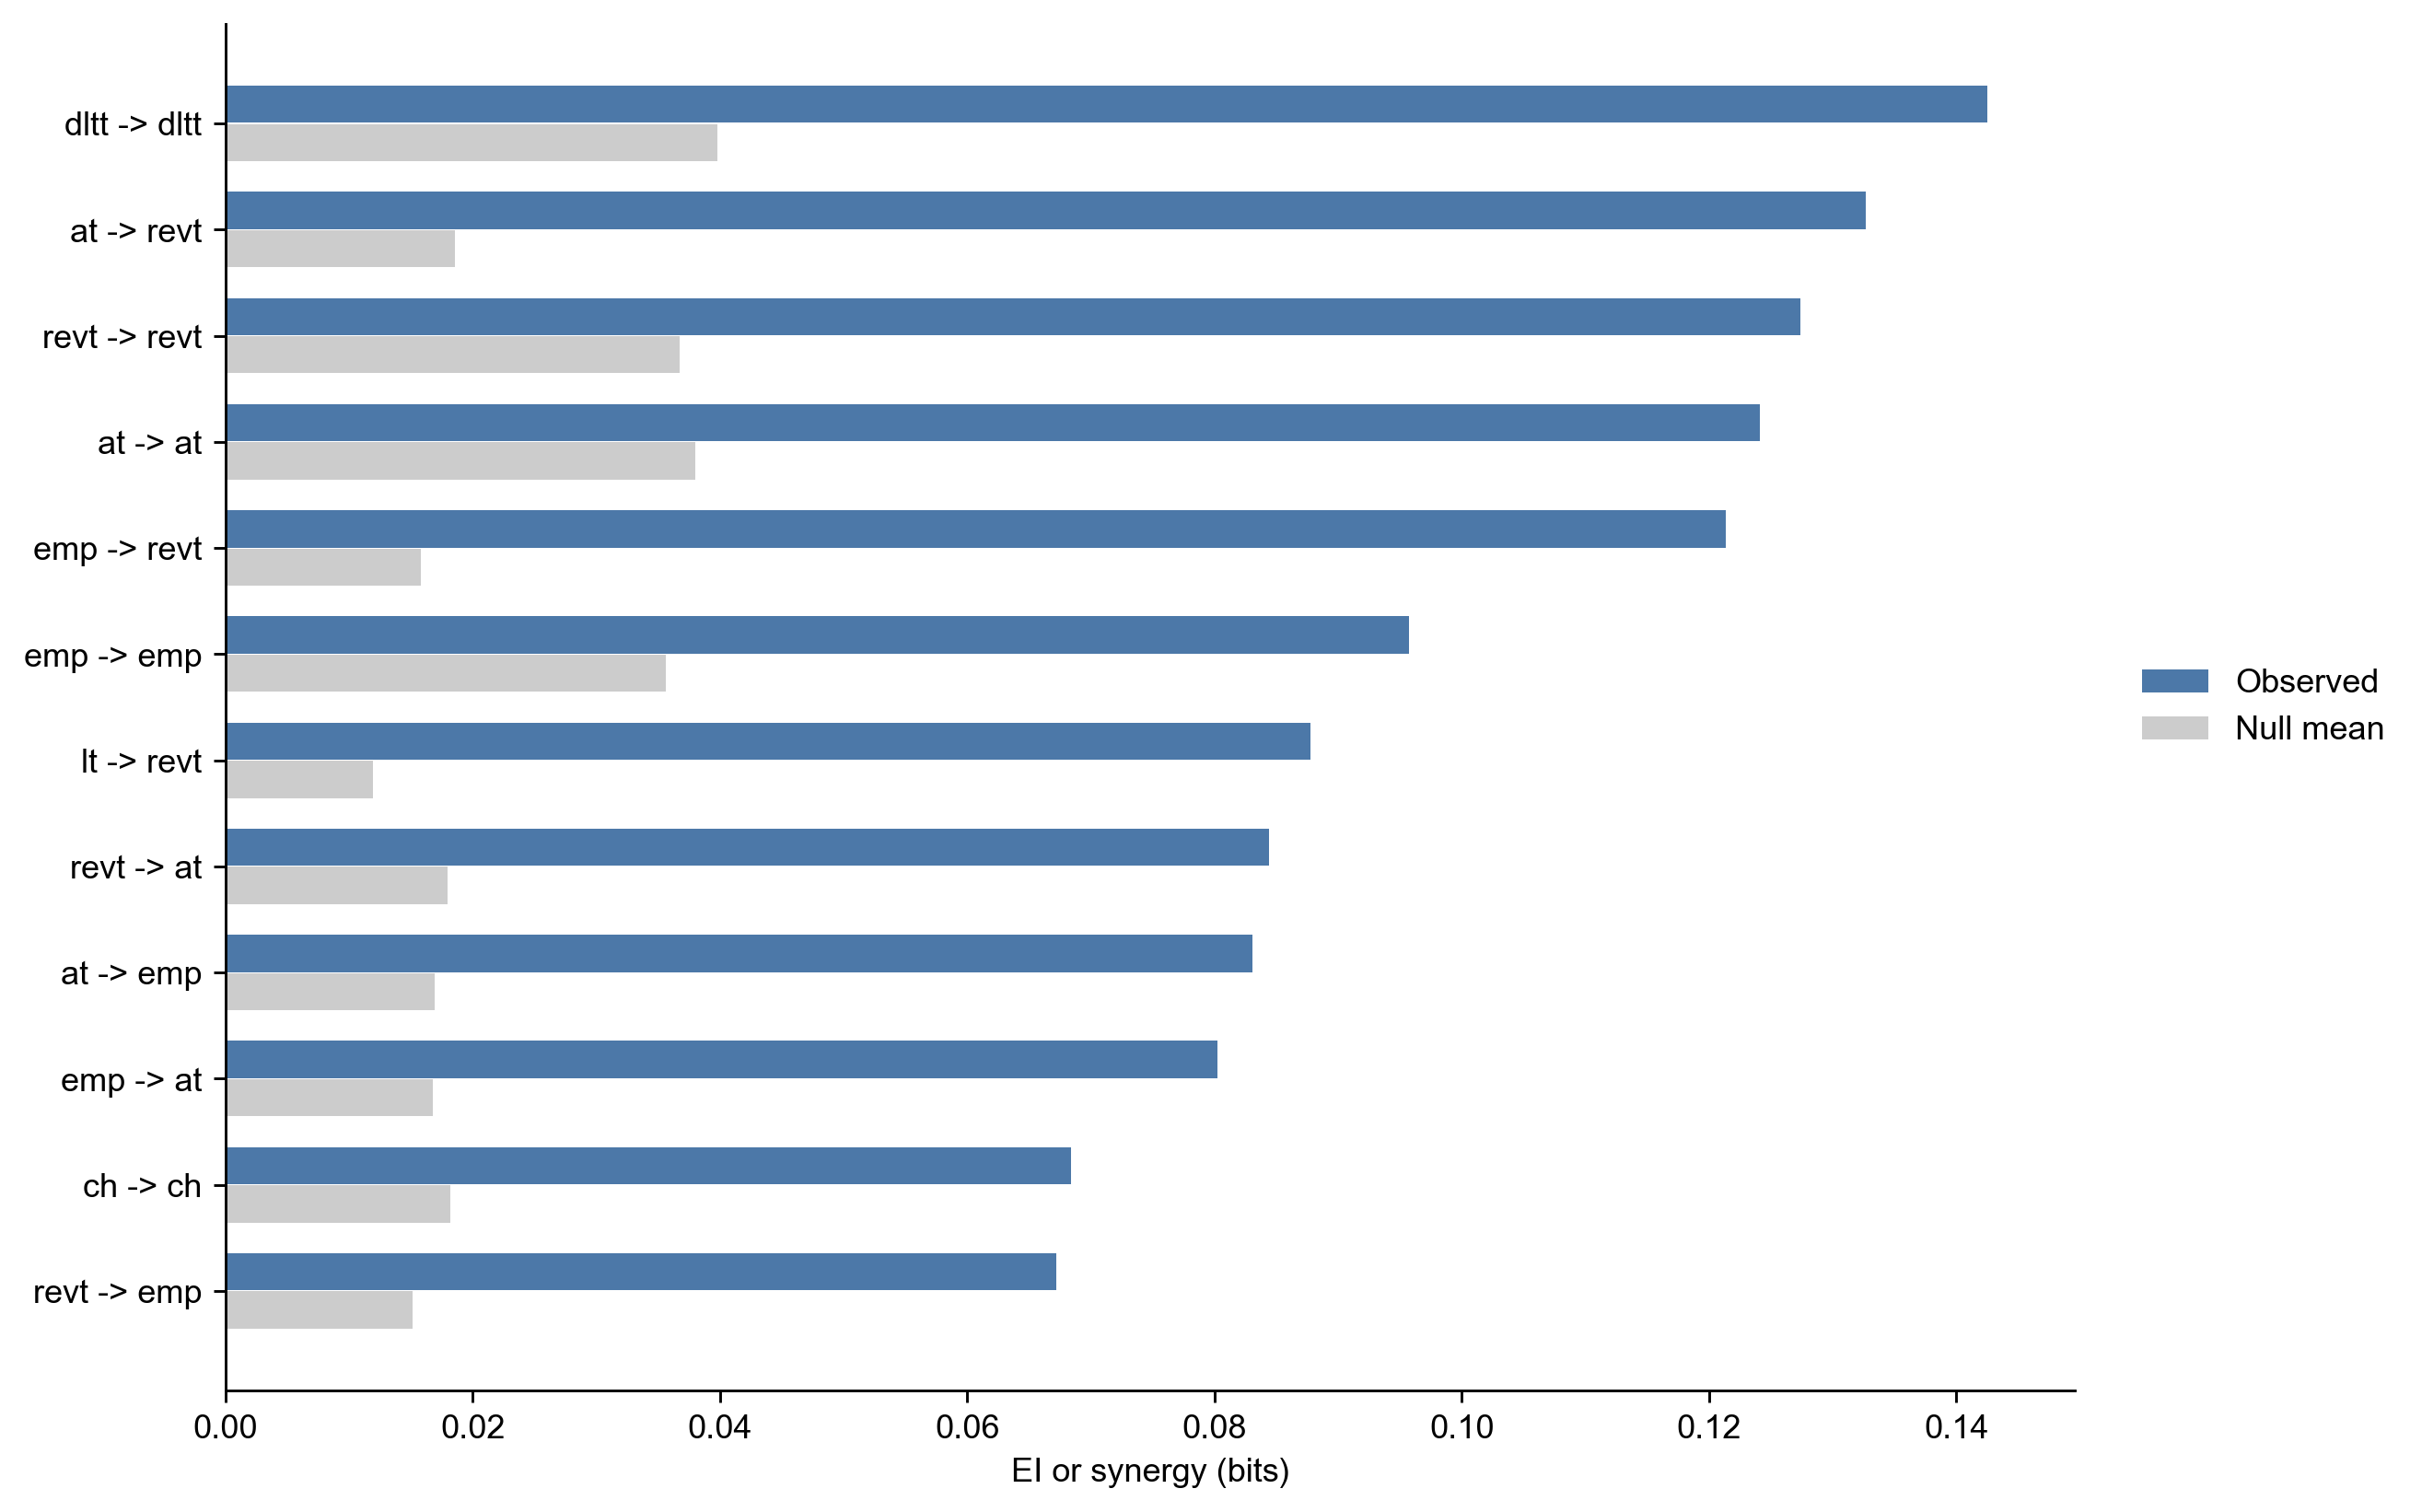

In [24]:
display(Image(filename=str(FIGURE_DIR / "peid_null_comparison.png")))

## 8. 时期稳定性

稳定性热图会在早期和晚期样本区间分别重新计算 Top 成对 EI 边。稳定的边应当在两个列中都保持可见。

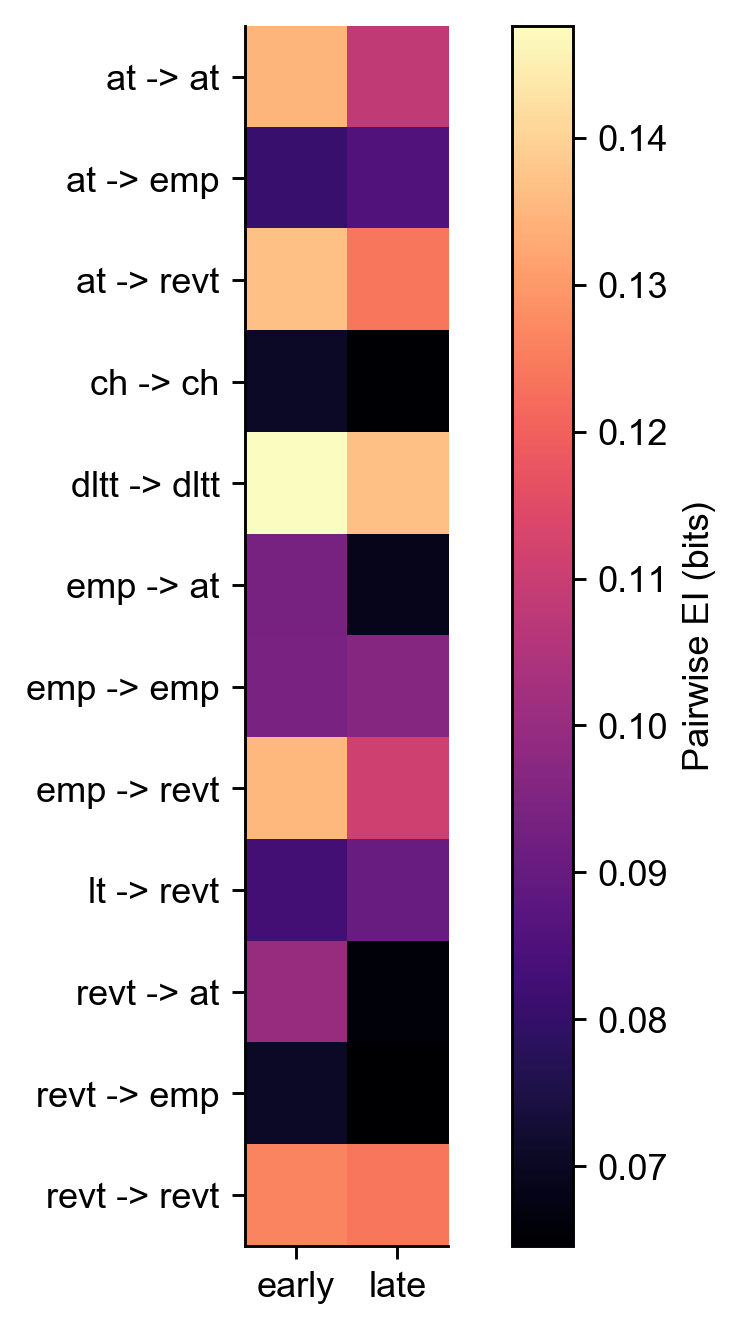

In [25]:
stability_fig = FIGURE_DIR / "peid_period_stability_heatmap.png"
if stability_fig.exists():
    display(Image(filename=str(stability_fig)))
else:
    print("当前参数设置未生成时期稳定性图。")

## 9. 手动调参说明

推荐调参顺序：

1. 先使用 `SMOKE` 或 3 个变量检查流水线。
2. 使用 6 个变量和 `BINS = 3` 生成第一版主要结果。
3. 将 `NULL_REPS` 提高到 100 或更多，用于形成最终证据。
4. 比较 `BINS = 3` 和 `BINS = 5`，评估离散化稳定性。
5. 只有在检查 `peid_variable_audit.csv` 和源状态支持度之后，再加入更多变量。